<a href="https://colab.research.google.com/github/CD-GRUPO3/TA047R-1C2025-GRUPO03/blob/main/TA047R_TP2_GRUPO03_CHPX_ENTREGA_N1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Grupo 3 - Trabajo Práctico 2
### Random Forest y XGBoost
**Integrantes:**
- ARIAS, Rafaela Pilar. 112272. rparias@fi.uba.ar.
- BARCALA ROCA, Ramiro. 112478. rbarcala@fi.uba.ar.
- LEMA, Mora. 111831. molema@fi.uba.ar.
- IENCO, Lara Eliana. 111921. lienco@fi.uba.ar.

---

 Bibliografía:
 - https://www.kaggle.com/code/gusthema/titanic-competition-w-tensorflow-decision-forests#Train-model-with-default-parameters

###Inicialización del entorno


In [1]:
#Importamos las bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Para el preprocesamiento de texto
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

In [2]:
!pip install nltk

import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
#Cargamos los datos al Notebook

!gdown 1rbGVg-g0_H4UxviHdM3KFEHv5_DjJd-P
!gdown 19RRGPOcV-gQojb7G3wCtu1pY2Q4fQs_y

Downloading...
From: https://drive.google.com/uc?id=1rbGVg-g0_H4UxviHdM3KFEHv5_DjJd-P
To: /content/test.csv
100% 11.1M/11.1M [00:00<00:00, 111MB/s]
Downloading...
From: https://drive.google.com/uc?id=19RRGPOcV-gQojb7G3wCtu1pY2Q4fQs_y
To: /content/train.csv
100% 72.2M/72.2M [00:00<00:00, 172MB/s]


In [4]:
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

print("Train - Columnas:", train_df.shape[1], "Filas:", train_df.shape[0])
print("Test - Columnas:", test_df.shape[1], "Filas:", test_df.shape[0])

print("\nPrimeras filas del train:")
display(train_df.head())

print("\nColumnas del train:")
print(train_df.columns)

print("\nDistribución de clases:")
print(train_df['sentimiento'].value_counts())


Train - Columnas: 3 Filas: 50000
Test - Columnas: 2 Filas: 8599

Primeras filas del train:


,ID,review_es,sentimiento
0,0,Uno de los otros críticos ha mencionado que de...,positivo
1,1,Una pequeña pequeña producción.La técnica de f...,positivo
2,2,Pensé que esta era una manera maravillosa de p...,positivo
3,3,"Básicamente, hay una familia donde un niño peq...",negativo
4,4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo



Columnas del train:
Index(['ID', 'review_es', 'sentimiento'], dtype='object')

Distribución de clases:
sentimiento
positivo    25000
negativo    25000
Name: count, dtype: int64


Observamos la cantidad de filas nulas en ambos conjuntos (train y test) y la cantidad de filas duplicadas

In [5]:
print("Cantidad total de valores NaN en el dataset train:", train_df.isnull().sum().sum())
print("Cantidad total de valores NaN en el dataset test:", test_df.isnull().sum().sum())

Cantidad total de valores NaN en el dataset train: 0
Cantidad total de valores NaN en el dataset test: 0


In [6]:
duplicadas_train = train_df.duplicated().sum()
print("Cantidad de filas duplicadas en el dataset train:", duplicadas_train)

duplicadas_test = test_df.duplicated().sum()
print("Cantidad de filas duplicadas en el dataset test:", duplicadas_test)

Cantidad de filas duplicadas en el dataset train: 0
Cantidad de filas duplicadas en el dataset test: 0


Al no haber duplicadas ni filas con NaN, no tuvimos que hacer nada al respecto.

###Preprocesamiento de los datos


Veamos si hay textos en otros idiomas que no sean español

In [7]:
!pip install langid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for langid: filename=langid-1.1.6-py3-none-any.whl size=1941216 sha256=8c43b9a950d0b540fd2e97b22d8159194824214f22b1930063595867b640a908
  Stored in directory: /root/.cache/pip/wheels/32/6a/b6/b7eb43a6ad55b139c15c5daa29f3707659cfa6944d3c696f5b
Successfully built langid


In [8]:
import langid

In [9]:
def detect_language(text):
    return langid.classify(str(text))[0]  # str() por si hay NaNs o números

train_df['language'] = train_df['review_es'].apply(detect_language)
test_df['language'] = test_df['review_es'].apply(detect_language)

Veamos cuántos idiomas hay y cuántas críticas por cada uno

In [10]:
conteo_idiomas_train = train_df['language'].value_counts()
print("Cantidad de idiomas en el dataset de entrenamiento: ", conteo_idiomas_train)
print(f"Cantidad de idiomas distintos: {train_df['language'].nunique()}")
conteo_idiomas_test = test_df['language'].value_counts()
print("\nCantidad de idiomas en el dataset de test: ", conteo_idiomas_test)


Cantidad de idiomas en el dataset de entrenamiento:  language
es    48179
en     1817
gl        2
pt        1
id        1
Name: count, dtype: int64
Cantidad de idiomas distintos: 5

Cantidad de idiomas en el dataset de test:  language
es    8597
ga       1
la       1
Name: count, dtype: int64


Nos quedamos sólo con las críticas en español

In [11]:
train_df = train_df[train_df['language'] == 'es'].copy()

In [12]:
print(train_df.shape)

(48179, 4)


In [13]:
train_df.columns

Index(['ID', 'review_es', 'sentimiento', 'language'], dtype='object')

In [14]:
train_df = train_df.drop(columns=['language', 'ID'])

###Limpieza y Tokenización


Veamos si las clases están balanceadas

In [15]:
train_df['sentimiento'].value_counts()

,count
sentimiento,
negativo,24131
positivo,24048


Separamos el dataset en entrenamiento 80% y test 20%

In [16]:
X = train_df['review_es']
y = train_df['sentimiento']

#Stratify para balancear la división
X_train_text, X_val_text, y_train, y_val = train_test_split(X,
                                                            y,
                                                            test_size = 0.2,
                                                            random_state = 42,
                                                            stratify = y
)


In [17]:
y_train.value_counts()

,count
sentimiento,
negativo,19305
positivo,19238


In [18]:
y_val.value_counts()

,count
sentimiento,
negativo,4826
positivo,4810


Limpieza de texto

In [19]:
def clean_text(text):
    text = text.lower()
    #re.sub(patron, remplazo, string) --> Devuelve el string con el patron reemplazado

    text = re.sub(r'([.,!?;:])', r' \1 ', text)  #Añade espacio después de puntos y comas si no hay (para que no se junten palabras)
    text = re.sub(r'[^a-záéíóúüñ\s]', '', text) #Reemplaza todo lo que no sea letra o espacio
    text = re.sub(r'\s+[a-záéíóúüñ]\s+', ' ', text)  #Elimina letras sueltas entre espacios
    text = re.sub(r'\s+', ' ', text) #Y si se me juntaron varios espacios, los mergeo en uno
    return text.strip()


Lematización

In [20]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 91.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [21]:
import spacy
nlp = spacy.load("es_core_news_sm")

def lemmatize_tokens(tokens):
    #Une los tokens en un string para procesar con spaCy
    text = " ".join(tokens)
    doc = nlp(text)
    return [
        token.lemma_.lower()
        for token in doc
        if token.is_alpha
        and token.lemma_.lower() not in stoplist
        and 2 <= len(token.lemma_) <= 20
        and len(set(token.lemma_)) > 1
    ]

In [22]:
#Defino la stoplist
stoplist = stopwords.words("spanish")
stoplist[:15]

['de',
 'la',
 'que',
 'el',
 'en',
 'y',
 'a',
 'los',
 'del',
 'se',
 'las',
 'por',
 'un',
 'para',
 'con']

In [23]:
def tokenizer(text):
    #Limpieza básica
    cleaned = clean_text(text)

    #Tokenización inicial
    tokens = word_tokenize(cleaned, language="spanish")
    tokens = [
        t.lower()
        for t in tokens
        if t.isalpha()
        and t.lower() not in stoplist
        and 2 <= len(t) <= 20
        and len(set(t.lower())) > 1
    ]

    #Luego lematizamos los tokens
    return lemmatize_tokens(tokens)

In [24]:
#Para chequear que estamos haciendo las cosas bien
ejemplo = X_train_text.sample(1).iloc[0]

print("Crítica original:")
print(ejemplo)
print("\nTexto limpio:")
print(clean_text(ejemplo))
print("\nTokens:")
print(tokenizer(clean_text(ejemplo)))

Crítica original:
Si hay un género en el que nunca he sido fanático, es el biopic. Siempre engañoso, lleno de información falsa, escenas sobre dramatizadas y trucos, casi, los biopics casi nunca se han hecho bien. Incluso en manos de los directores verdaderamente talentosos como Martin Scorsese (The Aviator) y Ron Howard (una mente hermosa), a menudo hacen un gran daño a las personas que están tratando de capturar en la pantalla. El escepticismo lleva el lugar de la exageración con la mayoría de los biopics que se dirigen a la pantalla grande y la notoria página de Bettie no era diferente. Algunos críticos y espectadores se opusieron a Gretchen Mol dado el papel de la página de Bettie, diciendo que ya no era una celebridad y no tenía las chuletas por la parte. Nunca dudé que Mol pudiera manejar la parte desde entonces, pero nunca esperaba que se tapara por su actuación, ya que estaba al simplemente ver las horas de la película. MOL ofrece un rendimiento digno de Oscar Knockout como la 

In [25]:
import warnings
warnings.filterwarnings("ignore", message="The parameter 'token_pattern' will not be used*")

vectorizer = CountVectorizer(
    preprocessor = clean_text,
    tokenizer = tokenizer,
    min_df = 10,        #Descarta palabras que aparecen en menos de 10 críticas
    max_df = 0.9       #Descarta palabras que aparecen en +90% de las críticas
)

X_train_vect = vectorizer.fit_transform(X_train_text)
X_val_vect = vectorizer.transform(X_val_text)

print("Cantidad de textos en entrenamiento:", X_train_vect.shape[0])
print("Cantidad de palabras distintas en entrenamiento:", X_train_vect.shape[1])
print("\n")

contador_palabras = np.array(X_train_vect.sum(axis = 0)).flatten() #Sumamos frecuencias por palabra
palabras = vectorizer.get_feature_names_out() #Obtenemos las palabras del vocabulario

#Armamos un DataFrame ordenado
freq_df = pd.DataFrame({'palabra': palabras, 'frecuencia': contador_palabras})
freq_df = freq_df.sort_values(by = 'frecuencia', ascending = False)

#Mostramos las 20 más frecuentes
display(freq_df.head(20))

Cantidad de textos en entrenamiento: 38543
Cantidad de palabras distintas en entrenamiento: 20084




,palabra,frecuencia
14165,película,114184
14629,poder,47968
8969,hacer,43915
19333,ver,39066
17070,ser,31691
17238,si,27992
17554,solo,24243
14170,películo,22967
19405,vez,21280
12252,mejor,18643


Previo a establecer y entrenar los modelos, implementamos una función para poder observar las métricas en el conjunto train y test.

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluar(y_true, y_pred, nombre):
    print(f"--- {nombre} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, pos_label='positivo'):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, pos_label='positivo'):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred, pos_label='positivo'):.4f}")
    print()

##Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

Vamos a buscar los mejores hiperparámetros utilizando GridSearch aplicando Cross Validation con 5 folds

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini'],
    'n_estimators': [200, 300, 400],
    'max_depth': [5, 10],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4, 6]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state = 42),
    param_grid,
    cv = 5,               #5-fold cross-validation
    scoring = 'f1_macro',
    n_jobs = -1,
)

grid_rf.fit(X_train_vect, y_train)

print("Mejores parámetros:", grid_rf.best_params_)
print("Mejor score de validación:", grid_rf.best_score_)

Mejores parámetros: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}
Mejor score de validación: 0.8295850039620648


Predecimos en el conjunto de train

Reporte de métricas - ENTRENAMIENTO
              precision    recall  f1-score   support

    negativo       0.89      0.81      0.85     19305
    positivo       0.82      0.90      0.86     19238

    accuracy                           0.85     38543
   macro avg       0.86      0.85      0.85     38543
weighted avg       0.86      0.85      0.85     38543

--- Random Forest con CounterVectorizer - Train ---
Accuracy : 0.8546
Precision: 0.8243
Recall   : 0.9006
F1 Score : 0.8607



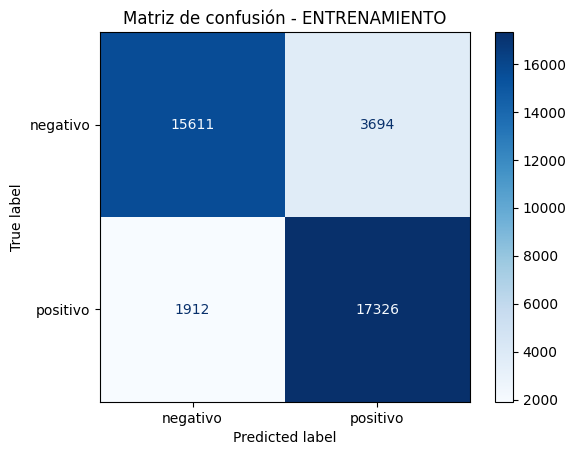



Reporte de métricas - VALIDACIÓN
              precision    recall  f1-score   support

    negativo       0.85      0.78      0.81      4826
    positivo       0.80      0.86      0.83      4810

    accuracy                           0.82      9636
   macro avg       0.82      0.82      0.82      9636
weighted avg       0.82      0.82      0.82      9636

--- Random Forest con CounterVectorizer - Validación ---
Accuracy : 0.8207
Precision: 0.7969
Recall   : 0.8599
F1 Score : 0.8272



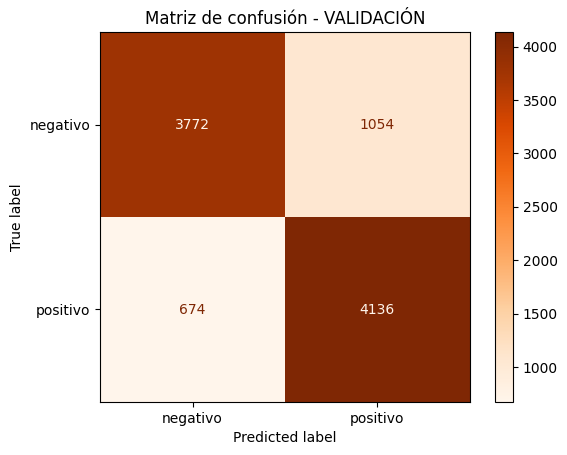

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_rf = grid_rf.best_estimator_

# Predecimos
y_train_pred = best_rf.predict(X_train_vect)
y_val_pred = best_rf.predict(X_val_vect)

# ---------- MÉTRICAS Y MATRIZ DE CONFUSIÓN: ENTRENAMIENTO ----------
print("Reporte de métricas - ENTRENAMIENTO")
print(classification_report(y_train, y_train_pred))
evaluar(y_train, y_train_pred, "Random Forest con CounterVectorizer - Train")

# Matriz de confusión - ENTRENAMIENTO
cm_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=best_rf.classes_)
disp_train.plot(cmap='Blues')
plt.title("Matriz de confusión - ENTRENAMIENTO")
plt.show()

# ---------- MÉTRICAS Y MATRIZ DE CONFUSIÓN: VALIDACIÓN ----------
print("\n" + "="*60 + "\n")
print("Reporte de métricas - VALIDACIÓN")
print(classification_report(y_val, y_val_pred))
evaluar(y_val, y_val_pred, "Random Forest con CounterVectorizer - Validación")

# Matriz de confusión - VALIDACIÓN
cm_val = confusion_matrix(y_val, y_val_pred)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=best_rf.classes_)
disp_val.plot(cmap='Oranges')
plt.title("Matriz de confusión - VALIDACIÓN")
plt.show()


Veamos con los mismos hiperparámetros si cambiando la vectorización las métricas mejoran

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfid_vectorizer = TfidfVectorizer(
    preprocessor = clean_text,
    tokenizer = tokenizer,
    min_df = 10, #antes era 15
    max_df = 0.9,
    ngram_range = (1, 2)
)


X_train_tfid = tfid_vectorizer.fit_transform(X_train_text)
X_val_tfid = tfid_vectorizer.transform(X_val_text)


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

#Modelo con TF-IDF

from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini'],
    'n_estimators': [200, 300, 400],
    'max_depth': [5, 10],
    'min_samples_split': [5, 10], #antes era [2, 5]
    'min_samples_leaf':  [2, 4, 6] #antes [1, 2, 3]
}

rf_tfid  = GridSearchCV(
    RandomForestClassifier(random_state = 42),
    param_grid,
    cv = 5,               #5-fold cross-validation
    scoring = 'f1_macro',
    n_jobs = -1,
)

rf_tfid.fit(X_train_tfid, y_train)
print("Mejores parámetros:", rf_tfid.best_params_)
print("Mejor score de validación:", rf_tfid.best_score_)


y_pred_tfid = rf_tfid.predict(X_val_tfid)

Mejores parámetros: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}
Mejor score de validación: 0.8352515489867877


Reporte de métricas - ENTRENAMIENTO
              precision    recall  f1-score   support

    negativo       0.90      0.82      0.86     19305
    positivo       0.83      0.91      0.87     19238

    accuracy                           0.86     38543
   macro avg       0.87      0.87      0.86     38543
weighted avg       0.87      0.86      0.86     38543

--- Random Forest con T-FID Vectorizer - Train ---
Accuracy : 0.8649
Precision: 0.8347
Recall   : 0.9096
F1 Score : 0.8705



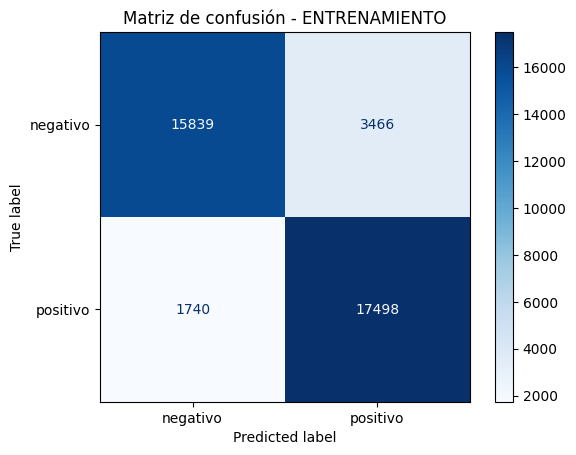



Reporte de métricas - VALIDACIÓN
              precision    recall  f1-score   support

    negativo       0.86      0.79      0.82      4826
    positivo       0.81      0.87      0.84      4810

    accuracy                           0.83      9636
   macro avg       0.83      0.83      0.83      9636
weighted avg       0.83      0.83      0.83      9636

--- Random Forest con T-FID Vectorizer - Validación ---
Accuracy : 0.8314
Precision: 0.8074
Recall   : 0.8696
F1 Score : 0.8374



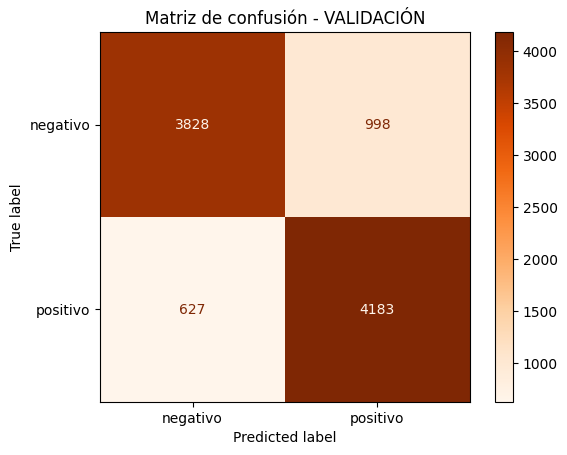

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predicciones de entrenamiento
y_train_pred_tfid = rf_tfid.predict(X_train_tfid)

# ---------- ENTRENAMIENTO ----------
print("Reporte de métricas - ENTRENAMIENTO")
print(classification_report(y_train, y_train_pred_tfid))
evaluar(y_train, y_train_pred_tfid, "Random Forest con T-FID Vectorizer - Train")

cm_train = confusion_matrix(y_train, y_train_pred_tfid)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=rf_tfid.best_estimator_.classes_)
disp_train.plot(cmap="Blues")
plt.title("Matriz de confusión - ENTRENAMIENTO")
plt.show()

# ---------- VALIDACIÓN ----------
print("\n" + "="*60 + "\n")
print("Reporte de métricas - VALIDACIÓN")
print(classification_report(y_val, y_pred_tfid))
evaluar(y_val, y_pred_tfid, "Random Forest con T-FID Vectorizer - Validación")

cm_val = confusion_matrix(y_val, y_pred_tfid)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=rf_tfid.best_estimator_.classes_)
disp_val.plot(cmap="Oranges")
plt.title("Matriz de confusión - VALIDACIÓN")
plt.show()


La diferencia es mínima pero mejora cuando usamos TFID-Vectorizer, así que evaluaremos con este método.

Predecimos sobre el conjunto de test

In [33]:
#Vectorizamos los textos de test
X_test_tfid = tfid_vectorizer.transform(test_df["review_es"])

#Predecimos con el mejor modelo
y_test_tfid = rf_tfid.predict(X_test_tfid)

#Creamos el dataframe para submissionz
submission = pd.DataFrame({
    "ID": test_df["ID"],
    "sentimiento": y_test_tfid
})

#Guardamos el archivo CSV para subir a Kaggle
submission.to_csv("submission_rf.csv", index = False)


In [34]:
#Con esto se descarga el archivo
from google.colab import files
files.download('submission_rf.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##XGBoost

Ahora vamos a entrenar el segundo modelo, el XGBoost

In [35]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 3.3 MB/s eta 0:00:00


In [36]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict

Para el XGBoost es necesario que las clases estén encodeadas como números y no texto, por lo que usamos label encoder para pasar el sentimiento negativo a 0 y el positivo a 1.

In [48]:
#Encodeamos las clases pos y neg para el XGBoost
#negativo → 0   ///   positivo → 1
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

#Hiperparámetros --> Espacio amplio de búsqueda
param_dist = {
    'n_estimators': [150, 250, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.5, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.8],
    'gamma': np.linspace(0, 5, 6),
    'reg_alpha': [0, 0.05, 0.1],
    'reg_lambda': [0.5, 1, 1.5]
}

xgb_clf = XGBClassifier(random_state=42)

xgb_random_search = RandomizedSearchCV(
    estimator = xgb_clf,
    param_distributions = param_dist,
    n_iter = 20,
    scoring = 'f1',
    cv = 4,
    verbose = 1,
    random_state = 42,
    n_jobs = -1
)

xgb_random_search.fit(X_train_vect, y_train_enc)

results = pd.DataFrame(xgb_random_search.cv_results_)
top5 = results.sort_values(by='rank_test_score').head(5)
top5_params = top5['params'].tolist()

Fitting 4 folds for each of 20 candidates, totalling 80 fits


In [49]:
for param in top5_params:
    print(param)

{'subsample': 0.5, 'reg_lambda': 1.5, 'reg_alpha': 0.05, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': np.float64(4.0), 'colsample_bytree': 0.8}
{'subsample': 0.7, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': np.float64(0.0), 'colsample_bytree': 0.6}
{'subsample': 0.5, 'reg_lambda': 1.5, 'reg_alpha': 0.05, 'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': np.float64(4.0), 'colsample_bytree': 0.6}
{'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.05, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': np.float64(5.0), 'colsample_bytree': 0.8}
{'subsample': 0.5, 'reg_lambda': 1.5, 'reg_alpha': 0.05, 'n_estimators': 250, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': np.float64(4.0), 'colsample_bytree': 0.8}


Ahora hacemos Grid Search con los 5 mejores parámetros

In [50]:
from sklearn.model_selection import GridSearchCV
base_params = top5_params[0]

#Ajustamos rangos alrededor del mejor conjunto
grid_params = {
    'n_estimators': [base_params['n_estimators'] - 50, base_params['n_estimators'], base_params['n_estimators'] + 50],
    'max_depth': [base_params['max_depth'] - 1, base_params['max_depth'], base_params['max_depth'] + 1],
    'learning_rate': [round(base_params['learning_rate'] * f, 3) for f in [0.8, 1.0, 1.2]],
    'subsample': [base_params['subsample']],
    'colsample_bytree': [base_params['colsample_bytree']],
}

xgb_grid_search = GridSearchCV(
    estimator = xgb_clf,
    param_grid = grid_params,
    scoring = 'f1',
    cv = 4,
    verbose = 1,
    n_jobs = -1
)

xgb_grid_search.fit(X_train_vect, y_train_enc)
print("Mejores parámetros:", xgb_grid_search.best_params_)

Fitting 4 folds for each of 27 candidates, totalling 108 fits
Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.12, 'max_depth': 6, 'n_estimators': 350, 'subsample': 0.5}


In [51]:
#Predicción y evaluación, de 0 y 1 se vuelve a neg y pos
y_train_pred = le.inverse_transform(xgb_grid_search.predict(X_train_vect))
y_val_pred = le.inverse_transform(xgb_grid_search.predict(X_val_vect))

print(classification_report(y_val, y_val_pred))

print("\n")
print("*"*20)
print("\n")

evaluar(y_train, y_train_pred, "XGBoost - Train")
evaluar(y_val, y_val_pred, "XGBoost - Validación")

#Predecimos sobre test
X_test_vect = vectorizer.transform(test_df["review_es"])
y_test_pred = xgb_grid_search.predict(X_test_vect)
y_test_pred_labels = le.inverse_transform(y_test_pred)

#Guardamos CSV para Kaggle
submission = pd.DataFrame({
    "ID": test_df["ID"],
    "sentimiento": y_test_pred_labels
})
submission.to_csv("submission_xgb.csv", index=False)


              precision    recall  f1-score   support

    negativo       0.86      0.84      0.85      4826
    positivo       0.85      0.86      0.85      4810

    accuracy                           0.85      9636
   macro avg       0.85      0.85      0.85      9636
weighted avg       0.85      0.85      0.85      9636



********************


--- XGBoost - Train ---
Accuracy : 0.9264
Precision: 0.9142
Recall   : 0.9408
F1 Score : 0.9273

--- XGBoost - Validación ---
Accuracy : 0.8518
Precision: 0.8451
Recall   : 0.8609
F1 Score : 0.8529



In [52]:
# Con esto se descarga el archivo
from google.colab import files
files.download('submission_xgb.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>